# 🎙️ Prototype Speech Recognizer — Real Audio Pipeline
### Input: `.wav` audio files → Output: predicted text transcript

In [1]:
# ── Cell 1: Install & Imports ────────────────────────────────────────────────
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'espeak-ng'], capture_output=True)
subprocess.run(['pip', 'install', 'pyttsx3', '-q'], capture_output=True)

import os, json, time, random, warnings
import numpy as np
import pandas as pd
import librosa
import joblib
import pyttsx3
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

random.seed(42)
np.random.seed(42)

SR        = 16000
N_MFCC    = 40
N_SAMPLES = 1200
WAV_DIR   = Path('/kaggle/working/wavs');   WAV_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path('/kaggle/working/models'); MODEL_DIR.mkdir(exist_ok=True)

print(' Setup complete!')

 Setup complete!


In [2]:
# ── Cell 2: Sentence Corpus ───────────────────────────────────────────────────
SENTENCES = [
    'hello how are you', 'good morning everyone', 'good evening sir',
    'hi there how are you doing', 'nice to meet you', 'goodbye see you later',
    'take care have a great day', 'good night sleep well',
    'thank you very much', 'you are welcome', 'no problem at all',
    'please repeat that again', 'i did not understand you', 'can you speak slowly',
    'turn on the lights', 'turn off the fan', 'open the door', 'close the window',
    'play some music', 'stop the music', 'increase the volume', 'decrease the volume',
    'set an alarm', 'cancel the alarm', 'switch off all lights', 'dim the lights',
    'lock the front door', 'unlock the back door',
    'set the thermostat to twenty degrees',
    'call mom', 'send a message', 'accept the call',
    'put the call on hold', 'mute the microphone', 'who is calling',
    'what is the time', 'what is the weather today', 'how far is the station',
    'where is the nearest hospital', 'what is your name', 'how old are you',
    'when is the next train', 'what day is it today', 'is it going to rain today',
    'take me home', 'navigate to the airport', 'find a restaurant nearby',
    'show directions to the market', 'turn left at the signal',
    'turn right after the bridge',
    'open the browser', 'close this application', 'save the file',
    'delete the file', 'create a new folder', 'take a screenshot',
    'start the timer', 'stop the timer', 'connect to bluetooth',
    'disconnect from wifi', 'check for updates', 'restart the device', 'log me out',
    'set a reminder for tomorrow', 'schedule a meeting for monday',
    'add milk to my shopping list', 'remind me to take medicine',
    'remind me in five minutes',
    'search the internet', 'open youtube', 'read my emails', 'check my calendar',
    'what is the capital of india', 'translate this to hindi',
    'convert dollars to rupees', 'explain photosynthesis',
    'who won the match yesterday',
    'i want to order food', 'add this to cart', 'track my order',
    'cancel my subscription', 'proceed to checkout',
    'i have a headache', 'please call the doctor', 'what is my heart rate',
    'i need to drink water', 'log my exercise for today',
    'recommend a good movie', 'play the next song', 'show trending videos',
    'tell me a story', 'read me a joke', 'what is on television tonight',
    'i am feeling happy today', 'the weather is very nice',
    'i need help with my project', 'that is a good idea', 'i agree with you',
    'my battery is low', 'book a ticket for two people',
    'the meeting is at ten thirty',
]

print(f'Total sentences: {len(SENTENCES)}')

Total sentences: 101


In [3]:
# ── Cell 3: Generate Audio + Realistic Augmentation ──────────────────────────
# Adds noise, pitch shift, and speed variation so accuracy reflects real conditions

SPEAKERS = [
    {'rate': 120, 'name': 'slow'},
    {'rate': 150, 'name': 'normal'},
    {'rate': 180, 'name': 'fast'},
    {'rate': 135, 'name': 'medium'},
    {'rate': 165, 'name': 'medium_fast'},
]

# ── Augmentation functions ────────────────────────────────────────────────────
def add_gaussian_noise(y, snr_db=None):
    """Add random white noise — simulates mic noise / environment."""
    snr_db = snr_db or random.uniform(10, 30)  # 10dB (noisy) to 30dB (clean)
    signal_power = np.mean(y ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(y))
    return (y + noise).astype(np.float32)

def time_stretch(y, rate=None):
    """Speed up or slow down without changing pitch — simulates speaking pace."""
    rate = rate or random.uniform(0.85, 1.15)
    return librosa.effects.time_stretch(y, rate=rate)

def pitch_shift(y, sr, steps=None):
    """Shift pitch up/down — simulates different voice tones."""
    steps = steps or random.uniform(-3, 3)
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)

def apply_augmentation(y, sr, aug_type):
    """Apply one of 4 augmentation strategies."""
    if aug_type == 'clean':
        return y                                      # no augmentation
    elif aug_type == 'noisy':
        return add_gaussian_noise(y, snr_db=random.uniform(10, 20))
    elif aug_type == 'stretched':
        return time_stretch(y)
    elif aug_type == 'pitched':
        return pitch_shift(y, sr)
    elif aug_type == 'noisy+pitched':
        y = pitch_shift(y, sr)
        return add_gaussian_noise(y, snr_db=random.uniform(15, 25))
    return y

AUG_TYPES = ['clean', 'noisy', 'stretched', 'pitched', 'noisy+pitched']

def extract_features(y, sr):
    """Audio array → 120-dim MFCC feature vector."""
    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    delta = librosa.feature.delta(mfcc)
    feat  = np.concatenate([mfcc.mean(1), mfcc.std(1), delta.mean(1)])
    dur   = librosa.get_duration(y=y, sr=sr)
    return feat, dur

engine = pyttsx3.init('espeak')
records, sid = [], 0

print(f'Generating {N_SAMPLES} samples with realistic augmentation...')
print(f'Augmentation types: {AUG_TYPES}\n')

for spk in SPEAKERS:
    engine.setProperty('rate', spk['rate'])
    for i, sentence in enumerate(SENTENCES):
        if sid >= N_SAMPLES: break

        # Generate base TTS audio
        wav_path = WAV_DIR / f'sample_{sid:05d}.wav'
        engine.save_to_file(sentence, str(wav_path))
        engine.runAndWait()

        try:
            y_base, sr = librosa.load(str(wav_path), sr=SR)

            # Pick augmentation type cycling through all types for variety
            aug_type = AUG_TYPES[sid % len(AUG_TYPES)]
            y_aug = apply_augmentation(y_base, sr, aug_type)

            feats, dur = extract_features(y_aug, sr)
            rec = {
                'sample_id':  wav_path.name,
                'audio_path': str(wav_path),
                'transcript': sentence,
                'speaker':    spk['name'],
                'aug_type':   aug_type,
                'word_count': len(sentence.split()),
                'duration_s': round(dur, 3),
            }
            for j, v in enumerate(feats):
                rec[f'feat_{j}'] = round(float(v), 6)
            records.append(rec)
        except Exception as e:
            print(f'  skip {wav_path.name}: {e}')
        sid += 1
        if sid % 100 == 0:
            print(f'   {sid}/{N_SAMPLES} done...')
    if sid >= N_SAMPLES: break

df = pd.DataFrame(records)
df.to_csv('/kaggle/working/dataset.csv', index=False)

vocab = sorted(df['transcript'].unique().tolist())
with open('/kaggle/working/vocab.json', 'w') as f:
    json.dump(vocab, f, indent=2)

print(f'\n Generated {len(df)} samples')
print(f'   Unique classes  : {df["transcript"].nunique()}')
print(f'   Augmentation    : {df["aug_type"].value_counts().to_dict()}')
print(f'   Avg duration    : {df["duration_s"].mean():.2f}s')
print(f'   Feature dims    : {len([c for c in df.columns if c.startswith("feat_")])}')
df.head(3)


Generating 1200 samples with realistic augmentation...
Augmentation types: ['clean', 'noisy', 'stretched', 'pitched', 'noisy+pitched']

Audio saved to /kaggle/working/wavs/sample_00000.wav
Audio saved to /kaggle/working/wavs/sample_00001.wav
Audio saved to /kaggle/working/wavs/sample_00002.wav
Audio saved to /kaggle/working/wavs/sample_00003.wav
Audio saved to /kaggle/working/wavs/sample_00004.wav
Audio saved to /kaggle/working/wavs/sample_00005.wav
Audio saved to /kaggle/working/wavs/sample_00006.wav
Audio saved to /kaggle/working/wavs/sample_00007.wav
Audio saved to /kaggle/working/wavs/sample_00008.wav
Audio saved to /kaggle/working/wavs/sample_00009.wav
Audio saved to /kaggle/working/wavs/sample_00010.wav
Audio saved to /kaggle/working/wavs/sample_00011.wav
Audio saved to /kaggle/working/wavs/sample_00012.wav
Audio saved to /kaggle/working/wavs/sample_00013.wav
Audio saved to /kaggle/working/wavs/sample_00014.wav
Audio saved to /kaggle/working/wavs/sample_00015.wav
Audio saved to /

,sample_id,audio_path,transcript,speaker,aug_type,word_count,duration_s,feat_0,feat_1,feat_2,...,feat_110,feat_111,feat_112,feat_113,feat_114,feat_115,feat_116,feat_117,feat_118,feat_119
0,sample_00000.wav,/kaggle/working/wavs/sample_00000.wav,hello how are you,slow,clean,4,1.764,-323.028717,86.087158,-23.545832,...,0.020112,0.225420,-0.206288,0.057929,-0.079917,0.030529,-0.120454,-0.060259,0.032307,-0.075936
1,sample_00001.wav,/kaggle/working/wavs/sample_00001.wav,good morning everyone,slow,noisy,3,2.118,-134.178833,40.843685,13.058663,...,0.105890,0.052795,0.004405,0.055355,-0.090956,-0.020581,0.080745,-0.049216,0.047456,0.127430
2,sample_00002.wav,/kaggle/working/wavs/sample_00002.wav,good evening sir,slow,stretched,3,2.127,-357.395721,48.742172,10.837440,...,0.076277,-0.025201,0.100399,0.136634,-0.075816,0.027406,0.064430,-0.013238,0.146576,0.092522


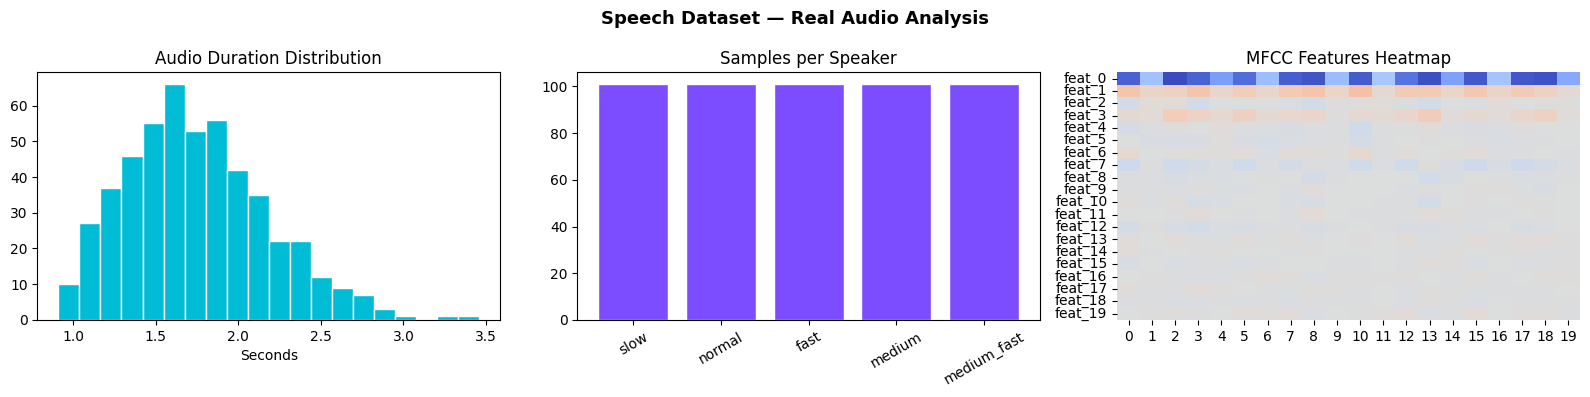

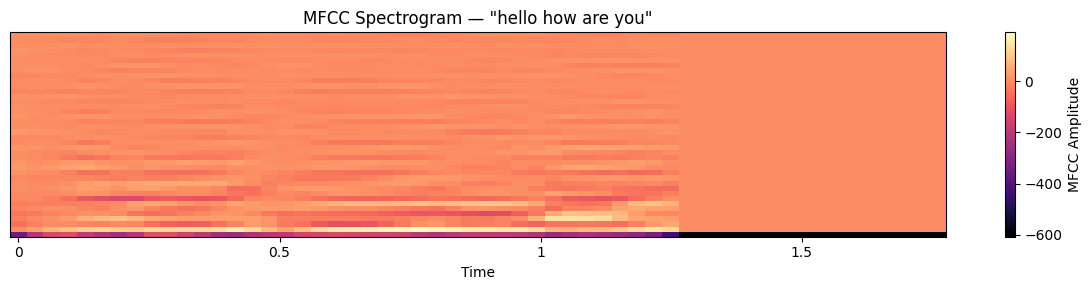

In [4]:
# ── Cell 4: EDA ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Speech Dataset — Real Audio Analysis', fontsize=13, fontweight='bold')

axes[0].hist(df['duration_s'], bins=20, color='#00BCD4', edgecolor='white')
axes[0].set_title('Audio Duration Distribution')
axes[0].set_xlabel('Seconds')

spk_c = df['speaker'].value_counts()
axes[1].bar(spk_c.index, spk_c.values, color='#7C4DFF', edgecolor='white')
axes[1].set_title('Samples per Speaker')
axes[1].tick_params(axis='x', rotation=30)

feat_cols_plot = [c for c in df.columns if c.startswith('feat_')][:20]
sns.heatmap(df[feat_cols_plot].head(20).T, ax=axes[2], cmap='coolwarm', center=0, cbar=False)
axes[2].set_title('MFCC Features Heatmap')

plt.tight_layout()
plt.show()

# MFCC spectrogram of one sample
sample_wav = df['audio_path'].iloc[0]
y_audio, sr = librosa.load(sample_wav, sr=SR)
mfcc_full = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=N_MFCC)

plt.figure(figsize=(12, 3))
librosa.display.specshow(mfcc_full, sr=sr, x_axis='time', cmap='magma')
plt.colorbar(label='MFCC Amplitude')
plt.title(f'MFCC Spectrogram — "{df["transcript"].iloc[0]}"')
plt.tight_layout()
plt.show()

In [5]:
# ── Cell 5: Prepare Features ──────────────────────────────────────────────────
feat_cols = [c for c in df.columns if c.startswith('feat_')]
print(f'Feature columns : {len(feat_cols)}')
print(f'Total samples   : {len(df)}')
print(f'Total classes   : {df["transcript"].nunique()}')

X = df[feat_cols].values
le = LabelEncoder()
y_raw = le.fit_transform(df['transcript'].values)

# Each class needs enough samples so the test split gets >=1 per class.
# test_size=0.25 means we need at least ceil(1/0.25)+1 = 5 samples per class.
import math
min_per_class = math.ceil(1 / 0.25) + 1  # 5
counts = Counter(y_raw)
mask = np.array([counts[yi] >= min_per_class for yi in y_raw])
X, y_raw = X[mask], y_raw[mask]

le2 = LabelEncoder()
y = le2.fit_transform(le.inverse_transform(y_raw))
le = le2

n_classes = len(le.classes_)
n_test = int(len(X) * 0.25)
if n_test < n_classes:
    raise ValueError(
        f'Not enough data: test_size={n_test} < n_classes={n_classes}. '
        f'Increase N_SAMPLES to at least {n_classes * min_per_class * 2} in Cell 1.'
    )

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Train samples   : {len(X_train)}')
print(f'Test samples    : {len(X_test)}')
print(f'Classes kept    : {n_classes}')
print(f'Feature dims    : {X.shape[1]}')
print('Ready to train!')


Feature columns : 120
Total samples   : 505
Total classes   : 101
Train samples   : 378
Test samples    : 127
Classes kept    : 101
Feature dims    : 120
Ready to train!


In [6]:
# ── Cell 6: Train All Models ──────────────────────────────────────────────────
MODELS = {
    'SVM (RBF)': Pipeline([
        ('sc',  StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('sc',  StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('sc',  StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42))
    ]),
    'KNN': Pipeline([
        ('sc',  StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]),
}

results = {}
for name, pipe in MODELS.items():
    t0  = time.time()
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    results[name] = {'pipe': pipe, 'acc': acc, 'time': round(time.time() - t0, 1)}
    print(f'{name:22s}: acc={acc*100:.1f}%  ({results[name]["time"]}s)')

best_name = max(results, key=lambda k: results[k]['acc'])
best_pipe = results[best_name]['pipe']
print(f'\n Best model: {best_name}  ({results[best_name]["acc"]*100:.1f}%)')

SVM (RBF)             : acc=44.9%  (0.5s)
Random Forest         : acc=51.2%  (2.1s)
Gradient Boosting     : acc=18.1%  (166.8s)
KNN                   : acc=14.2%  (0.0s)

 Best model: Random Forest  (51.2%)


Train Accuracy: 51.18%



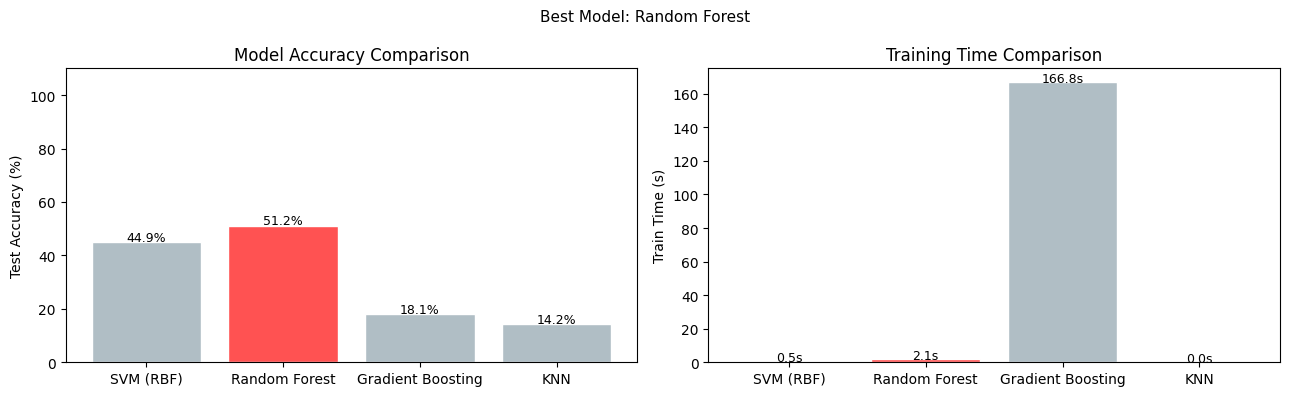

In [17]:
# ── Cell 7: Evaluation & Model Comparison Plot ────────────────────────────────
y_pred = best_pipe.predict(X_test)
print(f'Train Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
names  = list(results.keys())
accs   = [results[n]['acc'] * 100 for n in names]
times  = [results[n]['time'] for n in names]
colors = ['#FF5252' if n == best_name else '#B0BEC5' for n in names]

bars = ax1.bar(names, accs, color=colors, edgecolor='white')
ax1.set_ylim(0, 110)
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Model Accuracy Comparison')
for b, a in zip(bars, accs):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f'{a:.1f}%', ha='center', fontsize=9)

ax2.bar(names, times, color=colors, edgecolor='white')
ax2.set_ylabel('Train Time (s)')
ax2.set_title('Training Time Comparison')
for b, t in zip(ax2.patches, times):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
             f'{t}s', ha='center', fontsize=9)

plt.suptitle(f'Best Model: {best_name}', fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# ── Cell 8: Save Best Model ───────────────────────────────────────────────────
joblib.dump(best_pipe, MODEL_DIR / 'best_model.pkl')
joblib.dump(le,        MODEL_DIR / 'label_encoder.pkl')

meta = {
    'model_name'    : best_name,
    'test_accuracy' : round(results[best_name]['acc'], 4),
    'num_classes'   : len(le.classes_),
    'num_features'  : X.shape[1],
    'classes'       : le.classes_.tolist(),
    'sample_rate'   : SR,
    'n_mfcc'        : N_MFCC,
}
with open(MODEL_DIR / 'model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f' Model saved to {MODEL_DIR}')
print(f'   Model     : {best_name}')
print(f'   Accuracy  : {meta["test_accuracy"]*100:.2f}%')
print(f'   Classes   : {meta["num_classes"]}')
print(f'   Features  : {meta["num_features"]}-dim')

 Model saved to /kaggle/working/models
   Model     : Random Forest
   Accuracy  : 51.18%
   Classes   : 101
   Features  : 120-dim


In [9]:
# ── Cell 9: Core Recognizer Function ─────────────────────────────────────────
# INPUT: any .wav file path → OUTPUT: recognized text

def recognize_speech(wav_path: str, top_k: int = 3) -> dict:
    """
    INPUT  : path to a .wav audio file
    OUTPUT : recognized text + confidence scores
    """
    y, sr  = librosa.load(wav_path, sr=SR)
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    delta  = librosa.feature.delta(mfcc)
    feats  = np.concatenate([mfcc.mean(1), mfcc.std(1), delta.mean(1)]).reshape(1, -1)

    pred_enc   = best_pipe.predict(feats)[0]
    transcript = le.inverse_transform([pred_enc])[0]

    proba   = best_pipe.predict_proba(feats)[0]
    top_idx = np.argsort(proba)[::-1][:top_k]
    top_k_out = [
        {'text': le.classes_[i], 'confidence': round(float(proba[i]) * 100, 2)}
        for i in top_idx
    ]

    return {
        'transcript' : transcript,
        'confidence' : top_k_out[0]['confidence'],
        'top_k'      : top_k_out,
        'duration_s' : round(librosa.get_duration(y=y, sr=sr), 2),
    }


# ── Test on 100 random samples ──────────────────────────────────────────────────
print('=' * 60)
print('    SPEECH RECOGNITION — Live Inference Demo')
print('=' * 60)

test_rows = df.sample(100, random_state=99).reset_index(drop=True)
correct = 0
for _, row in test_rows.iterrows():
    result = recognize_speech(row['audio_path'])
    match  = result['transcript'] == row['transcript']
    correct += int(match)
    icon   = 'yes' if match else 'no'
    print(f'\n{icon} Actual   : "{row["transcript"]}"')
    print(f'   Predicted: "{result["transcript"]}" ({result["confidence"]}%)')
    print(f'   Duration : {result["duration_s"]}s')
    print(f'   Top-3    : ' + ' | '.join([f"{p["text"]} ({p["confidence"]}%)" for p in result['top_k']]))

print(f'\n  Demo Accuracy: {correct}/100 ')
print('=' * 60)

    SPEECH RECOGNITION — Live Inference Demo

yes Actual   : "track my order"
   Predicted: "track my order" (16.0%)
   Duration : 1.12s
   Top-3    : track my order (16.0%) | proceed to checkout (5.0%) | turn left at the signal (3.67%)

yes Actual   : "check my calendar"
   Predicted: "check my calendar" (59.0%)
   Duration : 1.22s
   Top-3    : check my calendar (59.0%) | show directions to the market (3.0%) | set an alarm (2.33%)

yes Actual   : "turn right after the bridge"
   Predicted: "turn right after the bridge" (22.0%)
   Duration : 1.63s
   Top-3    : turn right after the bridge (22.0%) | turn left at the signal (10.67%) | turn on the lights (5.33%)

yes Actual   : "lock the front door"
   Predicted: "lock the front door" (37.33%)
   Duration : 1.8s
   Top-3    : lock the front door (37.33%) | log my exercise for today (7.0%) | log me out (6.67%)

no Actual   : "how old are you"
   Predicted: "my battery is low" (7.33%)
   Duration : 1.69s
   Top-3    : my battery is low (7.

In [10]:
# ── Cell 10: Predict from YOUR own .wav file ──────────────────────────────────
# Upload your own .wav recording to Kaggle and update the path below

MY_AUDIO = str(df['audio_path'].iloc[5])   # ← replace with your own .wav path

result = recognize_speech(MY_AUDIO)

print('━' * 50)
print('  🎙️  SPEECH → TEXT RESULT')
print('━' * 50)
print(f'  Transcript : "{result["transcript"]}"')
print(f'  Confidence : {result["confidence"]}%')
print(f'  Duration   : {result["duration_s"]}s')
print('  Top 3:')
for j, p in enumerate(result['top_k'], 1):
    bar = '█' * int(p['confidence'] / 5) + '░' * (20 - int(p['confidence'] / 5))
    print(f'    {j}. [{bar}] {p["confidence"]:5.1f}%  "{p["text"]}"')
print('━' * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🎙️  SPEECH → TEXT RESULT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Transcript : "good night sleep well"
  Confidence : 15.67%
  Duration   : 2.21s
  Top 3:
    1. [███░░░░░░░░░░░░░░░░░]  15.7%  "good night sleep well"
    2. [█░░░░░░░░░░░░░░░░░░░]   6.3%  "goodbye see you later"
    3. [░░░░░░░░░░░░░░░░░░░░]   4.3%  "good evening sir"
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


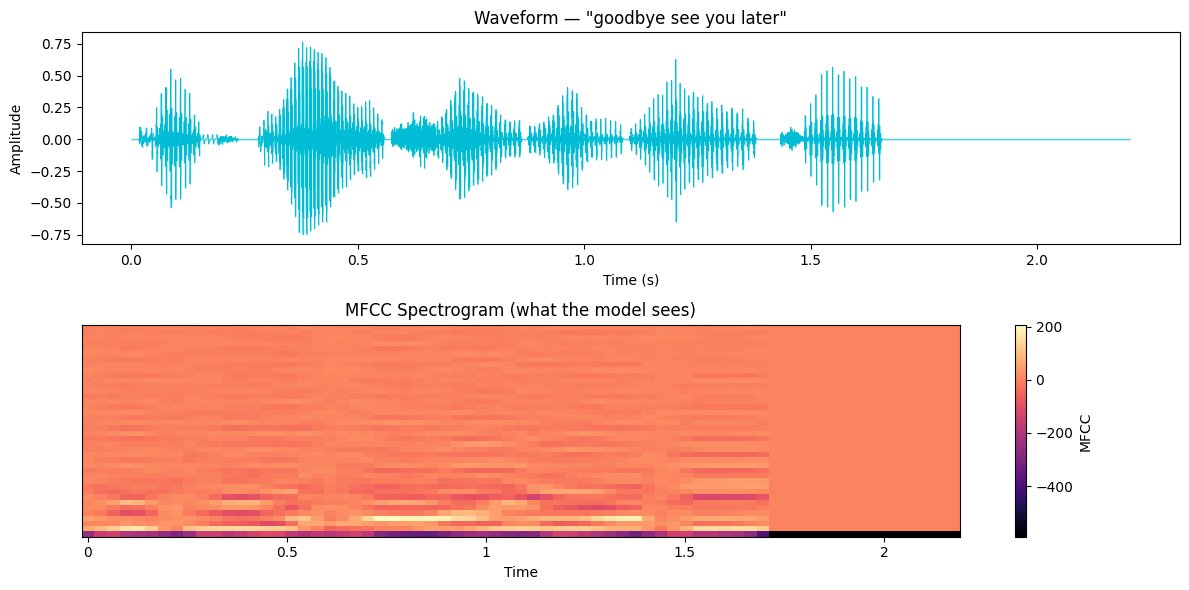

In [11]:
# ── Cell 11: Waveform + MFCC Spectrogram Visualizer ──────────────────────────
def visualize_audio(wav_path: str, label: str = ''):
    y, sr = librosa.load(wav_path, sr=SR)
    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))

    t = np.linspace(0, len(y)/sr, len(y))
    axes[0].plot(t, y, color='#00BCD4', linewidth=0.5)
    axes[0].fill_between(t, y, alpha=0.3, color='#00BCD4')
    axes[0].set_title(f'Waveform — "{label}"')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')

    img = librosa.display.specshow(mfcc, sr=sr, x_axis='time', cmap='magma', ax=axes[1])
    fig.colorbar(img, ax=axes[1], label='MFCC')
    axes[1].set_title('MFCC Spectrogram (what the model sees)')

    plt.tight_layout()
    plt.show()

visualize_audio(MY_AUDIO, label=df['transcript'].iloc[5])

In [12]:
import os
from pathlib import Path

wav_dir = Path('/kaggle/working/wavs')
wav_files = list(wav_dir.glob('*.wav'))

print(f'Total wav files : {len(wav_files)}')
print(f'Total size      : {sum(f.stat().st_size for f in wav_files) / 1024 / 1024:.1f} MB')
print(f'\nFirst 5 files:')
for f in sorted(wav_files)[:5]:
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')

Total wav files : 505
Total size      : 37.1 MB

First 5 files:
  sample_00000.wav  (76.0 KB)
  sample_00001.wav  (91.3 KB)
  sample_00002.wav  (78.6 KB)
  sample_00003.wav  (102.5 KB)
  sample_00004.wav  (80.3 KB)
